In [1]:
!pip -q install transformers accelerate sentencepiece pandas matplotlib

In [2]:
import os
import time
import math
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.cache_utils import DynamicCache

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("cuda version:", torch.version.cuda)

torch version: 2.10.0+cu128
cuda available: True
gpu: NVIDIA A100-SXM4-80GB
cuda version: 12.8


In [3]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASELINE_PROMPT_LENGTHS = [512, 1024, 2048]
WINDOW_SIZES = [512, 768, 1024]
MAX_NEW_TOKENS = 64
RUNS_PER_SETTING = 5

os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)

print("Using device:", DEVICE)

Using device: cuda


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    low_cpu_mem_usage=True
).to(DEVICE)

model.eval()
print("Model device:", next(model.parameters()).device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model device: cuda:0


In [5]:
def make_prompt(tokenizer, target_tokens: int) -> str:
    base_text = (
        "Large language models rely on key value caches during decoding. "
        "This project studies how prompt length affects decode latency, memory use, "
        "and overall inference efficiency. "
    )
    text = base_text
    while True:
        ids = tokenizer(text, return_tensors="pt")["input_ids"][0]
        if len(ids) >= target_tokens:
            break
        text += base_text
    trimmed_ids = ids[:target_tokens]
    return tokenizer.decode(trimmed_ids, skip_special_tokens=True)

In [6]:
warmup_prompt = "This is a warmup run for KV cache benchmarking."
warmup_inputs = tokenizer(warmup_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    _ = model.generate(
        **warmup_inputs,
        max_new_tokens=8,
        do_sample=False,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id
    )

if DEVICE == "cuda":
    torch.cuda.synchronize()

print("Warm-up complete.")

Warm-up complete.


In [7]:
def timed_greedy_generate(model, tokenizer, prompt, max_new_tokens=64):
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    generated_ids = input_ids.clone()

    # Prefill pass
    start_total = time.time()
    start_prefill = time.time()

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=True
        )

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    end_prefill = time.time()
    prefill_time = end_prefill - start_prefill

    logits = outputs.logits[:, -1, :]
    past_key_values = outputs.past_key_values

    next_token = torch.argmax(logits, dim=-1, keepdim=True)
    generated_ids = torch.cat([generated_ids, next_token], dim=-1)

    # TTFT: prompt processing + first token generation
    ttft = prefill_time

    # Decode remaining tokens
    decode_start = time.time()
    current_input = next_token
    new_tokens_generated = 1

    for _ in range(max_new_tokens - 1):
        with torch.no_grad():
            outputs = model(
                input_ids=current_input,
                use_cache=True,
                past_key_values=past_key_values
            )

        logits = outputs.logits[:, -1, :]
        past_key_values = outputs.past_key_values
        current_input = torch.argmax(logits, dim=-1, keepdim=True)
        generated_ids = torch.cat([generated_ids, current_input], dim=-1)
        new_tokens_generated += 1

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    decode_end = time.time()
    decode_time = decode_end - decode_start
    total_latency = time.time() - start_total

    peak_vram_mb = (
        torch.cuda.max_memory_allocated() / (1024 ** 2)
        if DEVICE == "cuda" else 0.0
    )

    generated_text = tokenizer.decode(
        generated_ids[0][input_ids.shape[1]:],
        skip_special_tokens=True
    )

    return {
        "prompt_tokens": int(input_ids.shape[1]),
        "generated_tokens": int(new_tokens_generated),
        "ttft_sec": ttft,
        "prefill_sec": prefill_time,
        "decode_sec": decode_time,
        "total_latency_sec": total_latency,
        "decode_sec_per_token": decode_time / max(new_tokens_generated, 1),
        "peak_vram_mb": peak_vram_mb,
        "generated_text": generated_text
    }

In [8]:
# ── Extended warmup for the manual decode path ────────────────────────────────
# The earlier warmup primes model.generate. The manual decode loop below uses
# different CUDA kernels and needs its own warmup to avoid JIT artifacts in run 1-3.
print("Running manual-decode warmup passes (results discarded)...")
_wp = make_prompt(tokenizer, 512)
for _i in range(3):
    _ = timed_greedy_generate(model, tokenizer, _wp, max_new_tokens=MAX_NEW_TOKENS)
    print(f"  warmup pass {_i+1}/3 complete")
if DEVICE == "cuda":
    torch.cuda.synchronize()
print("Manual-decode warmup complete.")

Running manual-decode warmup passes (results discarded)...
  warmup pass 1/3 complete
  warmup pass 2/3 complete
  warmup pass 3/3 complete
Manual-decode warmup complete.


In [ ]:
def legacy_tuple_to_dynamic_cache(legacy_cache):
    cache = DynamicCache()
    for layer_idx, layer_past in enumerate(legacy_cache):
        key_states, value_states = layer_past[:2]
        try:
            cache.update(key_states, value_states, layer_idx)
        except TypeError:
            cache.update(key_states, value_states, layer_idx, {})
    return cache


def cache_to_legacy_tuple(past_key_values):
    if past_key_values is None:
        return None
    if isinstance(past_key_values, (tuple, list)):
        return tuple(past_key_values)
    if hasattr(past_key_values, "to_legacy_cache"):
        return past_key_values.to_legacy_cache()
    try:
        maybe_tuple = tuple(past_key_values)
        if len(maybe_tuple) > 0 and isinstance(maybe_tuple[0], (tuple, list)):
            return maybe_tuple
    except TypeError:
        pass
    if hasattr(past_key_values, "key_cache") and hasattr(past_key_values, "value_cache"):
        return tuple(zip(past_key_values.key_cache, past_key_values.value_cache))
    raise TypeError(f"Unsupported cache type: {type(past_key_values)}")


def truncate_past_key_values(past_key_values, kv_budget, sink_size=4):
   
    if past_key_values is None:
        return None
    if kv_budget is None:
        if isinstance(past_key_values, (tuple, list)):
            return legacy_tuple_to_dynamic_cache(tuple(past_key_values))
        return past_key_values

    legacy_cache = cache_to_legacy_tuple(past_key_values)
    recent_size = max(kv_budget - sink_size, 1)

    trimmed_layers = []
    for layer_past in legacy_cache:
        key_states, value_states = layer_past[:2]
        seq_len = key_states.size(-2)

        if seq_len > kv_budget:
            # Sink tokens — always keep these
            sink_k = key_states[:, :, :sink_size, :]
            sink_v = value_states[:, :, :sink_size, :]
            # Most recent tokens
            recent_k = key_states[:, :, -recent_size:, :]
            recent_v = value_states[:, :, -recent_size:, :]
            # Final cache: [sink | recent]
            key_states = torch.cat([sink_k, recent_k], dim=-2).contiguous()
            value_states = torch.cat([sink_v, recent_v], dim=-2).contiguous()

        if len(layer_past) > 2:
            trimmed_layers.append((key_states, value_states, *layer_past[2:]))
        else:
            trimmed_layers.append((key_states, value_states))

    return legacy_tuple_to_dynamic_cache(tuple(trimmed_layers))

In [ ]:
def timed_windowed_kv_generate(model, tokenizer, prompt, max_new_tokens=64, kv_budget=512):
   
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    generated_ids = input_ids.clone()

    # ── Prefill ────────────────────────────────────────────────────────────────
    start_total = time.time()
    start_prefill = time.time()

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=True
        )

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    prefill_time = time.time() - start_prefill

    logits = outputs.logits[:, -1, :]
    past_key_values = outputs.past_key_values

    if isinstance(past_key_values, (tuple, list)):
        past_key_values = legacy_tuple_to_dynamic_cache(tuple(past_key_values))

    next_token = torch.argmax(logits, dim=-1, keepdim=True)
    generated_ids = torch.cat([generated_ids, next_token], dim=-1)
    ttft = prefill_time

    # ── Decode with eviction ───────────────────────────────────────────────────
    decode_start = time.time()
    current_input = next_token
    new_tokens_generated = 1
    next_position = input_ids.shape[1]
    decode_vram_mb = None

    for step in range(max_new_tokens - 1):
        # Apply StreamingLLM-style eviction
        past_key_values = truncate_past_key_values(past_key_values, kv_budget)

        # After the FIRST eviction, sample actual memory — this is the
        # steady-state decode footprint with the cache budget enforced.
        if step == 0 and DEVICE == "cuda":
            torch.cuda.synchronize()
            decode_vram_mb = torch.cuda.memory_allocated() / (1024 ** 2)

        effective_cache_len = past_key_values.get_seq_length()
        step_attention_mask = torch.ones(
            (1, effective_cache_len + 1), device=DEVICE, dtype=torch.long
        )
        step_position_ids = torch.tensor(
            [[next_position]], device=DEVICE, dtype=torch.long
        )

        with torch.no_grad():
            outputs = model(
                input_ids=current_input,
                use_cache=True,
                past_key_values=past_key_values,
                attention_mask=step_attention_mask,
                position_ids=step_position_ids
            )

        logits = outputs.logits[:, -1, :]
        past_key_values = outputs.past_key_values

        if isinstance(past_key_values, (tuple, list)):
            past_key_values = legacy_tuple_to_dynamic_cache(tuple(past_key_values))

        current_input = torch.argmax(logits, dim=-1, keepdim=True)
        generated_ids = torch.cat([generated_ids, current_input], dim=-1)
        new_tokens_generated += 1
        next_position += 1

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    decode_time = time.time() - decode_start
    total_latency = time.time() - start_total
    peak_vram_mb = (
        torch.cuda.max_memory_allocated() / (1024 ** 2) if DEVICE == "cuda" else 0.0
    )

    generated_text = tokenizer.decode(
        generated_ids[0][input_ids.shape[1]:], skip_special_tokens=True
    )

    return {
        "prompt_tokens": int(input_ids.shape[1]),
        "generated_tokens": int(new_tokens_generated),
        "kv_budget": kv_budget,
        "ttft_sec": ttft,
        "prefill_sec": prefill_time,
        "decode_sec": decode_time,
        "total_latency_sec": total_latency,
        "decode_sec_per_token": decode_time / max(new_tokens_generated, 1),
        "peak_vram_mb": peak_vram_mb,
        "decode_vram_mb": decode_vram_mb if decode_vram_mb is not None else peak_vram_mb,
        "generated_text": generated_text
    }

In [11]:
baseline_results = []

for prompt_len in BASELINE_PROMPT_LENGTHS:
    prompt = make_prompt(tokenizer, prompt_len)

    for run_idx in range(RUNS_PER_SETTING):
        result = timed_greedy_generate(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=MAX_NEW_TOKENS
        )
        result["run"] = run_idx + 1
        baseline_results.append(result)

        print(
            f"[Baseline] Prompt={result['prompt_tokens']}, Run={run_idx+1}, "
            f"TTFT={result['ttft_sec']:.4f}s, "
            f"Decode/token={result['decode_sec_per_token']:.4f}s, "
            f"Total={result['total_latency_sec']:.4f}s, "
            f"VRAM={result['peak_vram_mb']:.2f} MB"
        )

baseline_df = pd.DataFrame(baseline_results)
baseline_df.to_csv("results/baseline_results.csv", index=False)

baseline_summary = baseline_df.groupby("prompt_tokens", as_index=False).agg({
    "generated_tokens": "mean",
    "ttft_sec": "mean",
    "prefill_sec": "mean",
    "decode_sec": "mean",
    "total_latency_sec": "mean",
    "decode_sec_per_token": "mean",
    "peak_vram_mb": "mean"
})

baseline_summary.to_csv("results/baseline_summary.csv", index=False)
baseline_summary

[Baseline] Prompt=512, Run=1, TTFT=0.0295s, Decode/token=0.0242s, Total=1.5787s, VRAM=2153.31 MB
[Baseline] Prompt=512, Run=2, TTFT=0.0288s, Decode/token=0.0243s, Total=1.5810s, VRAM=2153.31 MB
[Baseline] Prompt=512, Run=3, TTFT=0.0290s, Decode/token=0.0243s, Total=1.5827s, VRAM=2153.31 MB
[Baseline] Prompt=512, Run=4, TTFT=0.0292s, Decode/token=0.0244s, Total=1.5898s, VRAM=2153.31 MB
[Baseline] Prompt=512, Run=5, TTFT=0.0292s, Decode/token=0.0245s, Total=1.5961s, VRAM=2153.31 MB
[Baseline] Prompt=1024, Run=1, TTFT=0.0390s, Decode/token=0.0247s, Total=1.6211s, VRAM=2196.83 MB
[Baseline] Prompt=1024, Run=2, TTFT=0.0317s, Decode/token=0.0246s, Total=1.6076s, VRAM=2196.83 MB
[Baseline] Prompt=1024, Run=3, TTFT=0.0315s, Decode/token=0.0244s, Total=1.5950s, VRAM=2196.83 MB
[Baseline] Prompt=1024, Run=4, TTFT=0.0318s, Decode/token=0.0244s, Total=1.5923s, VRAM=2196.83 MB


Token indices sequence length is longer than the specified maximum sequence length for this model (2076 > 2048). Running this sequence through the model will result in indexing errors


[Baseline] Prompt=1024, Run=5, TTFT=0.0315s, Decode/token=0.0244s, Total=1.5900s, VRAM=2196.83 MB
[Baseline] Prompt=2048, Run=1, TTFT=0.0448s, Decode/token=0.0244s, Total=1.6052s, VRAM=2293.37 MB
[Baseline] Prompt=2048, Run=2, TTFT=0.0404s, Decode/token=0.0244s, Total=1.6026s, VRAM=2293.37 MB
[Baseline] Prompt=2048, Run=3, TTFT=0.0406s, Decode/token=0.0245s, Total=1.6108s, VRAM=2293.37 MB
[Baseline] Prompt=2048, Run=4, TTFT=0.0404s, Decode/token=0.0244s, Total=1.6046s, VRAM=2293.37 MB
[Baseline] Prompt=2048, Run=5, TTFT=0.0404s, Decode/token=0.0240s, Total=1.5778s, VRAM=2293.37 MB


,prompt_tokens,generated_tokens,ttft_sec,prefill_sec,decode_sec,total_latency_sec,decode_sec_per_token,peak_vram_mb
0,512,64.0,0.029135,0.029135,1.556456,1.585674,0.024320,2153.314453
1,1024,64.0,0.033087,0.033087,1.568021,1.601202,0.024500,2196.826172
2,2048,64.0,0.041302,0.041302,1.558792,1.600199,0.024356,2293.369629


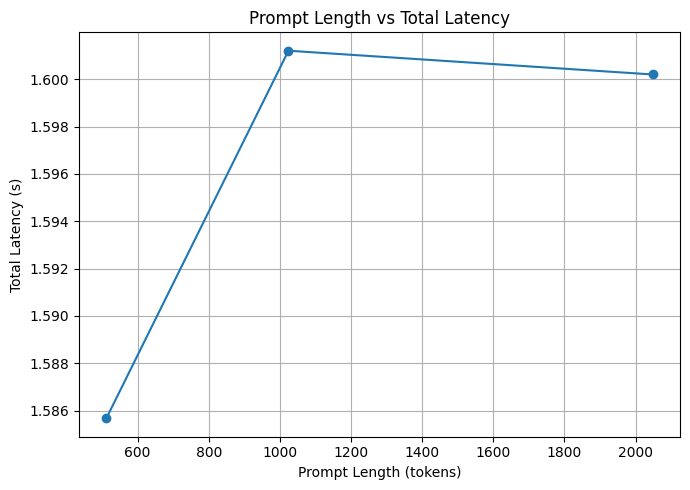

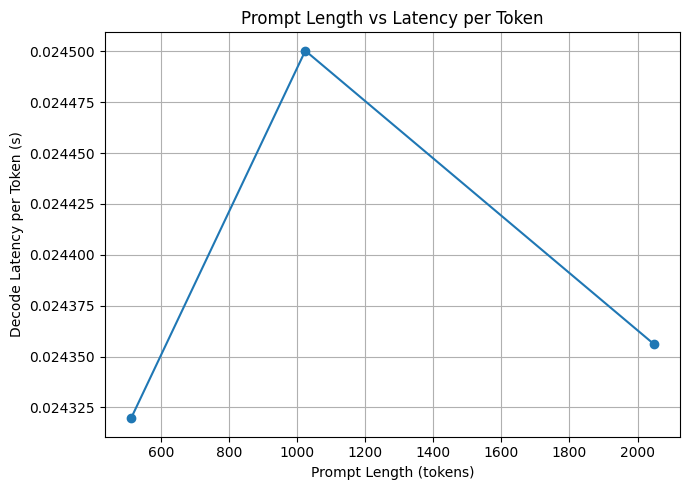

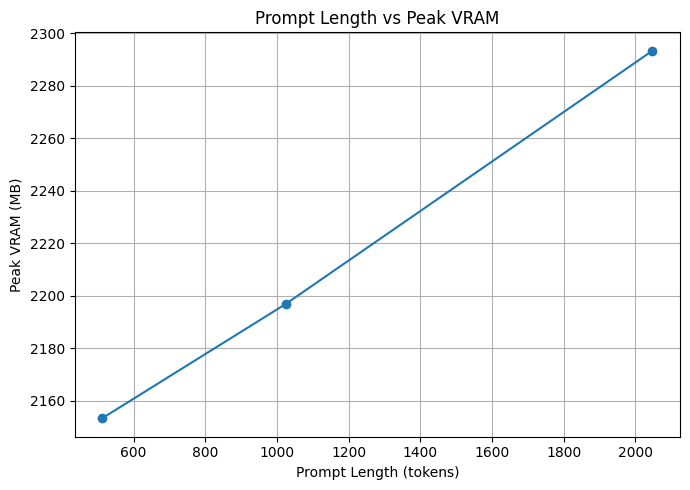

In [12]:
# Total latency
plt.figure(figsize=(7,5))
plt.plot(baseline_summary["prompt_tokens"], baseline_summary["total_latency_sec"], marker="o")
plt.xlabel("Prompt Length (tokens)")
plt.ylabel("Total Latency (s)")
plt.title("Prompt Length vs Total Latency")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/latency_vs_prompt_length.png")
plt.show()

# Latency per token
plt.figure(figsize=(7,5))
plt.plot(baseline_summary["prompt_tokens"], baseline_summary["decode_sec_per_token"], marker="o")
plt.xlabel("Prompt Length (tokens)")
plt.ylabel("Decode Latency per Token (s)")
plt.title("Prompt Length vs Latency per Token")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/latency_per_token_vs_prompt_length.png")
plt.show()

# Peak VRAM
plt.figure(figsize=(7,5))
plt.plot(baseline_summary["prompt_tokens"], baseline_summary["peak_vram_mb"], marker="o")
plt.xlabel("Prompt Length (tokens)")
plt.ylabel("Peak VRAM (MB)")
plt.title("Prompt Length vs Peak VRAM")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/vram_vs_prompt_length.png")
plt.show()

In [13]:
context_compare_results = []

comparisons = [
    {"mode": "reduced_context", "prompt_len": 512},
    {"mode": "full_context", "prompt_len": 1024},
]

for config in comparisons:
    prompt = make_prompt(tokenizer, config["prompt_len"])

    for run_idx in range(RUNS_PER_SETTING):
        result = timed_greedy_generate(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=MAX_NEW_TOKENS
        )
        result["mode"] = config["mode"]
        result["run"] = run_idx + 1
        context_compare_results.append(result)

        print(
            f"[{config['mode']}] Prompt={result['prompt_tokens']}, Run={run_idx+1}, "
            f"TTFT={result['ttft_sec']:.4f}s, "
            f"Decode/token={result['decode_sec_per_token']:.4f}s, "
            f"Total={result['total_latency_sec']:.4f}s, "
            f"VRAM={result['peak_vram_mb']:.2f} MB"
        )

context_compare_df = pd.DataFrame(context_compare_results)
context_compare_df.to_csv("results/context_compare_results.csv", index=False)

context_compare_summary = context_compare_df.groupby(["mode", "prompt_tokens"], as_index=False).agg({
    "generated_tokens": "mean",
    "ttft_sec": "mean",
    "prefill_sec": "mean",
    "decode_sec": "mean",
    "total_latency_sec": "mean",
    "decode_sec_per_token": "mean",
    "peak_vram_mb": "mean"
})

context_compare_summary.to_csv("results/context_compare_summary.csv", index=False)
context_compare_summary

[reduced_context] Prompt=512, Run=1, TTFT=0.0303s, Decode/token=0.0245s, Total=1.5977s, VRAM=2153.31 MB
[reduced_context] Prompt=512, Run=2, TTFT=0.0291s, Decode/token=0.0244s, Total=1.5922s, VRAM=2153.31 MB
[reduced_context] Prompt=512, Run=3, TTFT=0.0292s, Decode/token=0.0242s, Total=1.5749s, VRAM=2153.31 MB
[reduced_context] Prompt=512, Run=4, TTFT=0.0286s, Decode/token=0.0243s, Total=1.5816s, VRAM=2153.31 MB
[reduced_context] Prompt=512, Run=5, TTFT=0.0287s, Decode/token=0.0245s, Total=1.5956s, VRAM=2153.31 MB
[full_context] Prompt=1024, Run=1, TTFT=0.0323s, Decode/token=0.0247s, Total=1.6131s, VRAM=2196.83 MB
[full_context] Prompt=1024, Run=2, TTFT=0.0314s, Decode/token=0.0241s, Total=1.5770s, VRAM=2196.83 MB
[full_context] Prompt=1024, Run=3, TTFT=0.0317s, Decode/token=0.0241s, Total=1.5730s, VRAM=2196.83 MB
[full_context] Prompt=1024, Run=4, TTFT=0.0310s, Decode/token=0.0241s, Total=1.5749s, VRAM=2196.83 MB
[full_context] Prompt=1024, Run=5, TTFT=0.0311s, Decode/token=0.0241s, T

,mode,prompt_tokens,generated_tokens,ttft_sec,prefill_sec,decode_sec,total_latency_sec,decode_sec_per_token,peak_vram_mb
0,full_context,1024,64.0,0.031487,0.031487,1.550796,1.582374,0.024231,2196.826172
1,reduced_context,512,64.0,0.029186,0.029186,1.559124,1.588395,0.024361,2153.314453


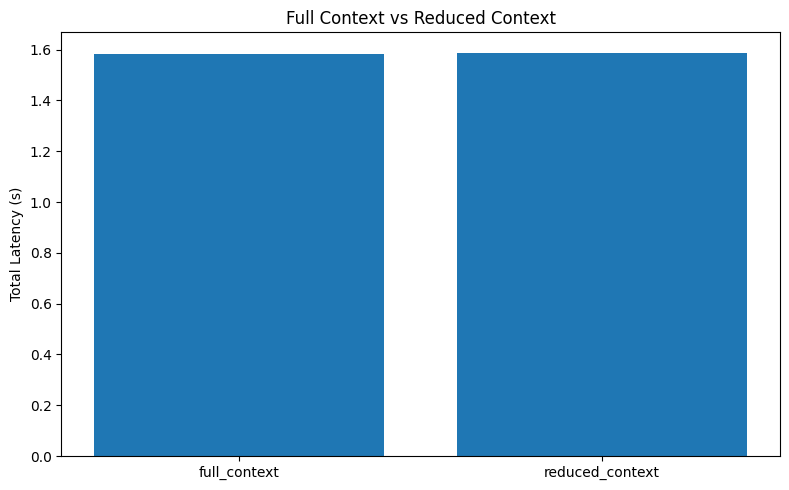

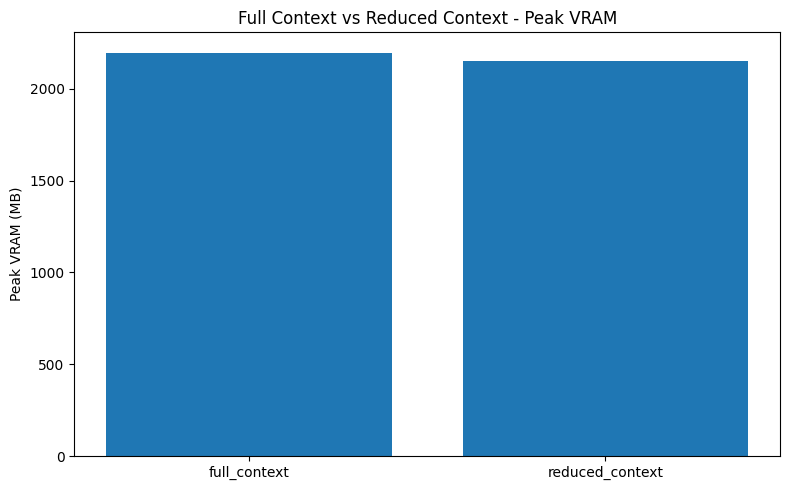

In [14]:
plt.figure(figsize=(8,5))
plt.bar(context_compare_summary["mode"], context_compare_summary["total_latency_sec"])
plt.ylabel("Total Latency (s)")
plt.title("Full Context vs Reduced Context")
plt.tight_layout()
plt.savefig("plots/full_vs_reduced_context_latency.png")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(context_compare_summary["mode"], context_compare_summary["peak_vram_mb"])
plt.ylabel("Peak VRAM (MB)")
plt.title("Full Context vs Reduced Context - Peak VRAM")
plt.tight_layout()
plt.savefig("plots/full_vs_reduced_context_vram.png")
plt.show()

In [15]:
actual_kv_results = []

ACTUAL_KV_SETTINGS = [
    ("full_cache",     None),
    ("kv_budget_1024", 1024),
    ("kv_budget_512",  512),
    ("kv_budget_256",  256),   # added — more aggressive eviction
]

ACTUAL_PROMPT_LEN = 2048
ACTUAL_RUNS = 5               # increased from 3

prompt = make_prompt(tokenizer, ACTUAL_PROMPT_LEN)

for mode, kv_budget in ACTUAL_KV_SETTINGS:
    for run_idx in range(ACTUAL_RUNS):
        if kv_budget is None:
            result = timed_greedy_generate(
                model=model, tokenizer=tokenizer,
                prompt=prompt, max_new_tokens=MAX_NEW_TOKENS
            )
            result["mode"] = mode
            result["kv_budget"] = -1
            result["decode_vram_mb"] = result["peak_vram_mb"]
        else:
            result = timed_windowed_kv_generate(
                model=model, tokenizer=tokenizer,
                prompt=prompt, max_new_tokens=MAX_NEW_TOKENS,
                kv_budget=kv_budget
            )
            result["mode"] = mode

        result["run"] = run_idx + 1
        actual_kv_results.append(result)

        print(
            f"[KV-Opt] Mode={mode}, Run={run_idx+1}, "
            f"Decode/tok={result['decode_sec_per_token']*1000:.1f}ms, "
            f"PeakVRAM={result['peak_vram_mb']:.0f}MB, "
            f"DecodeVRAM={result['decode_vram_mb']:.0f}MB | "
            f"Text: {result['generated_text'][:60]!r}"
        )

actual_kv_df = pd.DataFrame(actual_kv_results)
actual_kv_df.to_csv("results/actual_kv_optimization_results.csv", index=False)

mode_order = ["full_cache", "kv_budget_1024", "kv_budget_512", "kv_budget_256"]

actual_kv_summary = actual_kv_df.groupby("mode", as_index=False).agg(
    prompt_tokens=("prompt_tokens", "mean"),
    generated_tokens=("generated_tokens", "mean"),
    ttft_sec=("ttft_sec", "mean"),
    prefill_sec=("prefill_sec", "mean"),
    decode_sec=("decode_sec", "mean"),
    total_latency_sec=("total_latency_sec", "mean"),
    decode_sec_per_token=("decode_sec_per_token", "mean"),
    peak_vram_mb=("peak_vram_mb", "mean"),
    decode_vram_mb=("decode_vram_mb", "mean"),
)
actual_kv_summary["mode"] = pd.Categorical(
    actual_kv_summary["mode"], categories=mode_order, ordered=True
)
actual_kv_summary = actual_kv_summary.sort_values("mode").reset_index(drop=True)
actual_kv_summary.to_csv("results/actual_kv_optimization_summary.csv", index=False)
actual_kv_summary

[KV-Opt] Mode=full_cache, Run=1, Decode/tok=24.3ms, PeakVRAM=2293MB, DecodeVRAM=2293MB | Text: 'value caches during decoding. This project studies how promp'
[KV-Opt] Mode=full_cache, Run=2, Decode/tok=24.4ms, PeakVRAM=2293MB, DecodeVRAM=2293MB | Text: 'value caches during decoding. This project studies how promp'
[KV-Opt] Mode=full_cache, Run=3, Decode/tok=25.0ms, PeakVRAM=2293MB, DecodeVRAM=2293MB | Text: 'value caches during decoding. This project studies how promp'
[KV-Opt] Mode=full_cache, Run=4, Decode/tok=24.7ms, PeakVRAM=2293MB, DecodeVRAM=2293MB | Text: 'value caches during decoding. This project studies how promp'
[KV-Opt] Mode=full_cache, Run=5, Decode/tok=24.4ms, PeakVRAM=2293MB, DecodeVRAM=2293MB | Text: 'value caches during decoding. This project studies how promp'
[KV-Opt] Mode=kv_budget_1024, Run=1, Decode/tok=26.5ms, PeakVRAM=2322MB, DecodeVRAM=2300MB | Text: 'value caches during decoding. This project studies how promp'
[KV-Opt] Mode=kv_budget_1024, Run=2, Decode/tok=

,mode,prompt_tokens,generated_tokens,ttft_sec,prefill_sec,decode_sec,total_latency_sec,decode_sec_per_token,peak_vram_mb,decode_vram_mb
0,full_cache,2048.0,64.0,0.041259,0.041259,1.570918,1.612270,0.024546,2293.369629,2293.369629
1,kv_budget_1024,2048.0,64.0,0.040081,0.040081,1.709312,1.749480,0.026708,2322.350586,2300.350586
2,kv_budget_512,2048.0,64.0,0.040277,0.040277,1.694624,1.734992,0.026479,2300.350586,2289.350586
3,kv_budget_256,2048.0,64.0,0.040394,0.040394,1.694824,1.735308,0.026482,2289.350586,2283.850586


/tmp/ipykernel_580/3660358046.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(actual_kv_summary["mode"], rotation=20, ha="right")
/tmp/ipykernel_580/3660358046.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(actual_kv_summary["mode"], rotation=20, ha="right")


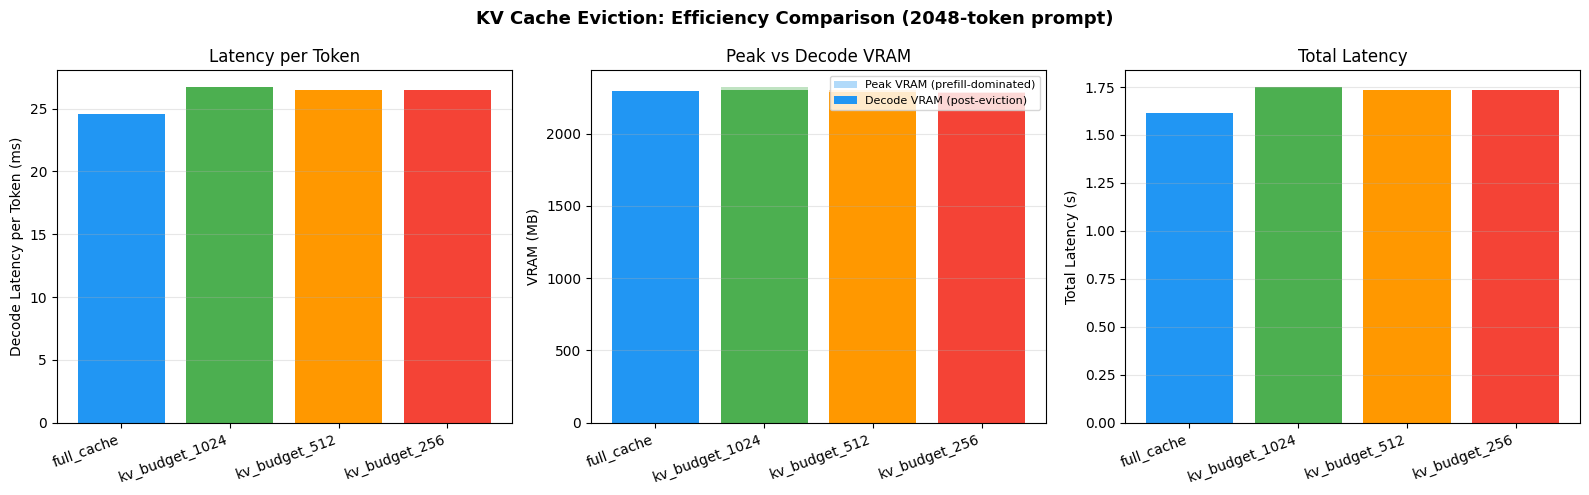

In [16]:
mode_order = ["full_cache", "kv_budget_1024", "kv_budget_512", "kv_budget_256"]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: decode latency per token
axes[0].bar(actual_kv_summary["mode"], actual_kv_summary["decode_sec_per_token"] * 1000, color=colors)
axes[0].set_ylabel("Decode Latency per Token (ms)")
axes[0].set_title("Latency per Token")
axes[0].set_xticklabels(actual_kv_summary["mode"], rotation=20, ha="right")
axes[0].grid(axis="y", alpha=0.3)

# Panel 2: peak VRAM vs decode VRAM (shows what eviction actually frees)
x = range(len(actual_kv_summary))
axes[1].bar(x, actual_kv_summary["peak_vram_mb"], color=colors, alpha=0.35, label="Peak VRAM (prefill-dominated)")
axes[1].bar(x, actual_kv_summary["decode_vram_mb"], color=colors, label="Decode VRAM (post-eviction)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(actual_kv_summary["mode"], rotation=20, ha="right")
axes[1].set_ylabel("VRAM (MB)")
axes[1].set_title("Peak vs Decode VRAM")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

# Panel 3: total latency
axes[2].bar(actual_kv_summary["mode"], actual_kv_summary["total_latency_sec"], color=colors)
axes[2].set_ylabel("Total Latency (s)")
axes[2].set_title("Total Latency")
axes[2].set_xticklabels(actual_kv_summary["mode"], rotation=20, ha="right")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("KV Cache Eviction: Efficiency Comparison (2048-token prompt)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/actual_kv_comparison.png", dpi=150)
plt.show()

In [17]:
# ── Quality Evaluation: Perplexity of generated continuations ────────────────
# For each KV mode, generate text, then score that continuation using the FULL
# model (no eviction, teacher-forced). Lower perplexity = better quality.
# This gives the Pareto tradeoff: efficiency vs quality degradation.

EVAL_PROMPT_LENGTHS = [512, 1024, 2048]
EVAL_KV_SETTINGS = [
    ("full_cache",     None),
    ("kv_budget_1024", 1024),
    ("kv_budget_512",  512),
    ("kv_budget_256",  256),
]

perplexity_results = []
print("Computing perplexity for each KV mode (this takes a few minutes)...")

for plen in EVAL_PROMPT_LENGTHS:
    eval_prompt = make_prompt(tokenizer, plen)
    prompt_ids = tokenizer(eval_prompt, return_tensors="pt")["input_ids"].to(DEVICE)

    for mode, kv_budget in EVAL_KV_SETTINGS:
        # Step 1: generate with the chosen KV mode
        if kv_budget is None:
            gen = timed_greedy_generate(model, tokenizer, eval_prompt, max_new_tokens=MAX_NEW_TOKENS)
        else:
            gen = timed_windowed_kv_generate(model, tokenizer, eval_prompt,
                                             max_new_tokens=MAX_NEW_TOKENS, kv_budget=kv_budget)

        generated_text = gen["generated_text"]

        # Step 2: score continuation with full model (no eviction)
        cont_ids = tokenizer(generated_text, return_tensors="pt",
                             add_special_tokens=False)["input_ids"].to(DEVICE)

        if cont_ids.shape[1] == 0:
            ppl = float("inf")
        else:
            full_input = torch.cat([prompt_ids, cont_ids], dim=1)
            labels = torch.full_like(full_input, -100)
            labels[:, prompt_ids.shape[1]:] = cont_ids  # score only the generated part

            with torch.no_grad():
                loss = model(input_ids=full_input, labels=labels).loss
            ppl = torch.exp(loss).item()

        perplexity_results.append({
            "prompt_tokens": int(prompt_ids.shape[1]),
            "mode": mode,
            "kv_budget": kv_budget if kv_budget else -1,
            "perplexity": round(ppl, 2),
            "generated_text_preview": generated_text[:120],
        })
        print(f"  prompt={plen}tok | {mode}: perplexity = {ppl:.2f}")
        print(f"    output: {generated_text[:80]!r}")

ppl_df = pd.DataFrame(perplexity_results)
ppl_df.to_csv("results/perplexity_results.csv", index=False)

ppl_summary = ppl_df.groupby("mode", as_index=False).agg(avg_perplexity=("perplexity", "mean"))
print("\nAverage perplexity by mode:")
print(ppl_summary.sort_values("avg_perplexity").to_string(index=False))

Computing perplexity for each KV mode (this takes a few minutes)...
  prompt=512tok | full_cache: perplexity = 2.72
    output: "\n\nBased on the text material, can you provide a summary of the project's main fi"
  prompt=512tok | kv_budget_1024: perplexity = 2.72
    output: "\n\nBased on the text material, can you provide a summary of the project's main fi"
  prompt=512tok | kv_budget_512: perplexity = 2.61
    output: '\n\nBased on the text material, what are the main findings of the research project'
  prompt=512tok | kv_budget_256: perplexity = 3.18
    output: '\n\nThe project will involve the following activities:\n\n1. Data collection: The pr'
  prompt=1024tok | full_cache: perplexity = 1.00
    output: 'models rely on key value caches during decoding. This project studies how prompt'
  prompt=1024tok | kv_budget_1024: perplexity = 1.00
    output: 'models rely on key value caches during decoding. This project studies how prompt'
  prompt=1024tok | kv_budget_512: perplexity = 1

,mode,decode_ms_per_token,decode_vram_mb,avg_perplexity,latency_delta_%,vram_delta_%,ppl_delta_%
0,full_cache,24.55,2293.4,1.57,0.0,0.0,0.0
1,kv_budget_1024,26.71,2300.4,1.57,8.8,0.3,0.0
2,kv_budget_512,26.48,2289.4,1.54,7.9,-0.2,-2.3
3,kv_budget_256,26.48,2283.9,1.73,7.9,-0.4,9.7


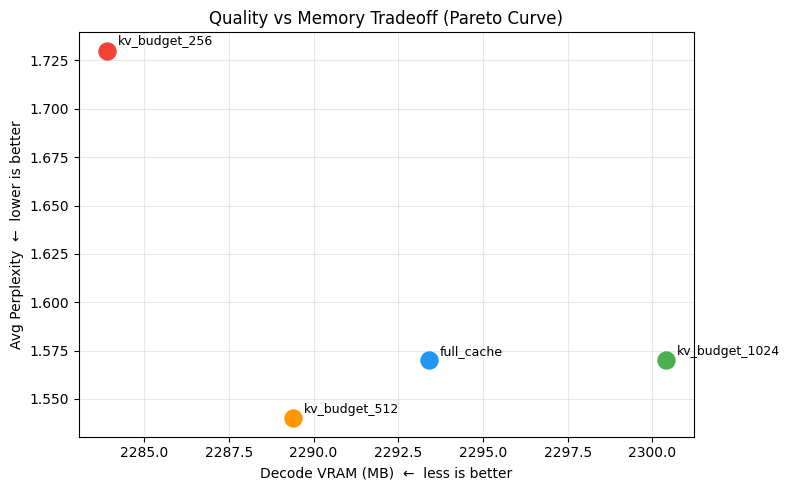

In [18]:
# ── Pareto Tradeoff Table ─────────────────────────────────────────────────────
baseline_ppl     = ppl_summary[ppl_summary["mode"] == "full_cache"]["avg_perplexity"].values[0]
baseline_latency = actual_kv_summary[actual_kv_summary["mode"] == "full_cache"]["decode_sec_per_token"].values[0] * 1000
baseline_vram    = actual_kv_summary[actual_kv_summary["mode"] == "full_cache"]["decode_vram_mb"].values[0]

tradeoff_rows = []
for _, row in actual_kv_summary.iterrows():
    mode = row["mode"]
    ppl_val = ppl_summary[ppl_summary["mode"] == mode]["avg_perplexity"].values
    avg_ppl = ppl_val[0] if len(ppl_val) > 0 else float("nan")

    tradeoff_rows.append({
        "mode": mode,
        "decode_ms_per_token": round(row["decode_sec_per_token"] * 1000, 2),
        "decode_vram_mb": round(row["decode_vram_mb"], 1),
        "avg_perplexity": round(avg_ppl, 2),
        "latency_delta_%": round((row["decode_sec_per_token"] * 1000 - baseline_latency) / baseline_latency * 100, 1),
        "vram_delta_%": round((row["decode_vram_mb"] - baseline_vram) / baseline_vram * 100, 1),
        "ppl_delta_%": round((avg_ppl - baseline_ppl) / baseline_ppl * 100, 1),
    })

tradeoff_df = pd.DataFrame(tradeoff_rows)
tradeoff_df.to_csv("results/tradeoff_table.csv", index=False)
display(tradeoff_df)

# Pareto curve: perplexity vs decode VRAM
colors_map = {
    "full_cache":     "#2196F3",
    "kv_budget_1024": "#4CAF50",
    "kv_budget_512":  "#FF9800",
    "kv_budget_256":  "#F44336",
}

plt.figure(figsize=(8, 5))
for _, row in tradeoff_df.iterrows():
    plt.scatter(row["decode_vram_mb"], row["avg_perplexity"],
                color=colors_map.get(row["mode"], "gray"), s=150, zorder=5)
    plt.annotate(row["mode"], (row["decode_vram_mb"], row["avg_perplexity"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)

plt.xlabel("Decode VRAM (MB)  ←  less is better")
plt.ylabel("Avg Perplexity  ←  lower is better")
plt.title("Quality vs Memory Tradeoff (Pareto Curve)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pareto_tradeoff.png", dpi=150)
plt.show()

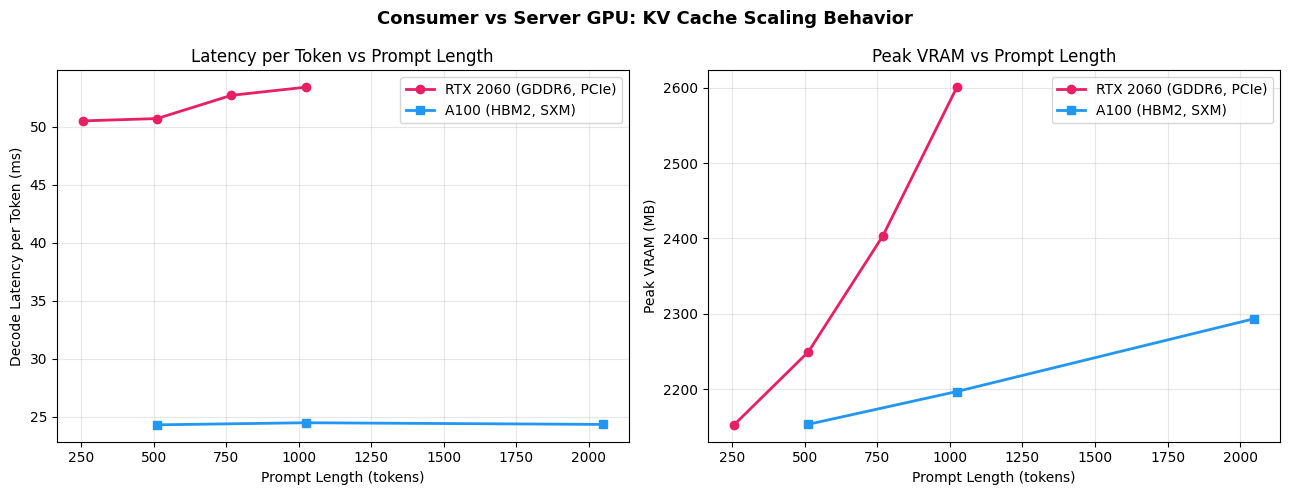

Decode latency comparison at overlapping prompt lengths:
  512 tokens → RTX 2060: 50.7 ms/tok | A100: 24.3 ms/tok | speedup: 2.1x
  1024 tokens → RTX 2060: 53.4 ms/tok | A100: 24.5 ms/tok | speedup: 2.2x

VRAM scaling (512→1024 tokens):
  RTX 2060: 2250 → 2601 MB
  A100:     2153 → 2197 MB


In [ ]:
# ── Hardware Comparison: RTX 2060 vs A100 ────────────────────────────────────

rtx2060_df = pd.DataFrame({
    "prompt_tokens":        [256,   512,   768,   1024],
    "decode_ms_per_token":  [50.5,  50.7,  52.7,  53.4],
    "peak_vram_mb":         [2152.6, 2249.5, 2402.8, 2600.6],
})

a100_df = baseline_summary[["prompt_tokens", "decode_sec_per_token", "peak_vram_mb"]].copy()
a100_df["decode_ms_per_token"] = a100_df["decode_sec_per_token"] * 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Decode latency per token
axes[0].plot(rtx2060_df["prompt_tokens"], rtx2060_df["decode_ms_per_token"],
             marker="o", label="RTX 2060 (GDDR6, PCIe)", color="#E91E63", linewidth=2)
axes[0].plot(a100_df["prompt_tokens"], a100_df["decode_ms_per_token"],
             marker="s", label="A100 (HBM2, SXM)", color="#2196F3", linewidth=2)
axes[0].set_xlabel("Prompt Length (tokens)")
axes[0].set_ylabel("Decode Latency per Token (ms)")
axes[0].set_title("Latency per Token vs Prompt Length")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Peak VRAM
axes[1].plot(rtx2060_df["prompt_tokens"], rtx2060_df["peak_vram_mb"],
             marker="o", label="RTX 2060 (GDDR6, PCIe)", color="#E91E63", linewidth=2)
axes[1].plot(a100_df["prompt_tokens"], a100_df["peak_vram_mb"],
             marker="s", label="A100 (HBM2, SXM)", color="#2196F3", linewidth=2)
axes[1].set_xlabel("Prompt Length (tokens)")
axes[1].set_ylabel("Peak VRAM (MB)")
axes[1].set_title("Peak VRAM vs Prompt Length")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Consumer vs Server GPU: KV Cache Scaling Behavior", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/hardware_comparison.png", dpi=150)
plt.show()

# Print key numbers
print("Decode latency comparison at overlapping prompt lengths:")
for pl in [512, 1024]:
    rtx_val = rtx2060_df[rtx2060_df["prompt_tokens"] == pl]["decode_ms_per_token"].values[0]
    a100_val = a100_df[a100_df["prompt_tokens"] == pl]["decode_ms_per_token"].values[0]
    print(f"  {pl} tokens → RTX 2060: {rtx_val:.1f} ms/tok | A100: {a100_val:.1f} ms/tok | speedup: {rtx_val/a100_val:.1f}x")

print("\nVRAM scaling (512→1024 tokens):")
print(f"  RTX 2060: {rtx2060_df[rtx2060_df['prompt_tokens']==512]['peak_vram_mb'].values[0]:.0f} → "
      f"{rtx2060_df[rtx2060_df['prompt_tokens']==1024]['peak_vram_mb'].values[0]:.0f} MB")
print(f"  A100:     {a100_df[a100_df['prompt_tokens']==512]['peak_vram_mb'].values[0]:.0f} → "
      f"{a100_df[a100_df['prompt_tokens']==1024]['peak_vram_mb'].values[0]:.0f} MB")

In [20]:
ablation_results = []

BASE_PROMPT_LEN = 1024

for window_size in WINDOW_SIZES:
    prompt = make_prompt(tokenizer, window_size)

    for run_idx in range(RUNS_PER_SETTING):
        result = timed_greedy_generate(
            model=model,
            tokenizer=tokenizer,
            prompt=prompt,
            max_new_tokens=MAX_NEW_TOKENS
        )
        result["window_size"] = window_size
        result["run"] = run_idx + 1
        ablation_results.append(result)

        print(
            f"[Ablation] Window={window_size}, Run={run_idx+1}, "
            f"TTFT={result['ttft_sec']:.4f}s, "
            f"Decode/token={result['decode_sec_per_token']:.4f}s, "
            f"Total={result['total_latency_sec']:.4f}s, "
            f"VRAM={result['peak_vram_mb']:.2f} MB"
        )

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv("results/window_ablation_results.csv", index=False)

ablation_summary = ablation_df.groupby("window_size", as_index=False).agg({
    "generated_tokens": "mean",
    "ttft_sec": "mean",
    "prefill_sec": "mean",
    "decode_sec": "mean",
    "total_latency_sec": "mean",
    "decode_sec_per_token": "mean",
    "peak_vram_mb": "mean"
})

ablation_summary.to_csv("results/window_ablation_summary.csv", index=False)
ablation_summary

[Ablation] Window=512, Run=1, TTFT=0.0304s, Decode/token=0.0241s, Total=1.5719s, VRAM=2153.36 MB
[Ablation] Window=512, Run=2, TTFT=0.0283s, Decode/token=0.0241s, Total=1.5683s, VRAM=2153.36 MB
[Ablation] Window=512, Run=3, TTFT=0.0284s, Decode/token=0.0244s, Total=1.5885s, VRAM=2153.36 MB
[Ablation] Window=512, Run=4, TTFT=0.0295s, Decode/token=0.0240s, Total=1.5656s, VRAM=2153.36 MB
[Ablation] Window=512, Run=5, TTFT=0.0284s, Decode/token=0.0241s, Total=1.5738s, VRAM=2153.36 MB
[Ablation] Window=768, Run=1, TTFT=0.0295s, Decode/token=0.0241s, Total=1.5730s, VRAM=2175.74 MB
[Ablation] Window=768, Run=2, TTFT=0.0290s, Decode/token=0.0243s, Total=1.5857s, VRAM=2175.74 MB
[Ablation] Window=768, Run=3, TTFT=0.0291s, Decode/token=0.0240s, Total=1.5627s, VRAM=2175.74 MB
[Ablation] Window=768, Run=4, TTFT=0.0289s, Decode/token=0.0239s, Total=1.5611s, VRAM=2175.74 MB
[Ablation] Window=768, Run=5, TTFT=0.0294s, Decode/token=0.0244s, Total=1.5884s, VRAM=2175.74 MB
[Ablation] Window=1024, Run=1,

,window_size,generated_tokens,ttft_sec,prefill_sec,decode_sec,total_latency_sec,decode_sec_per_token,peak_vram_mb
0,512,64.0,0.029028,0.029028,1.544520,1.573628,0.024133,2153.363281
1,768,64.0,0.029177,0.029177,1.544922,1.574180,0.024139,2175.744141
2,1024,64.0,0.031064,0.031064,1.527946,1.559096,0.023874,2196.875000


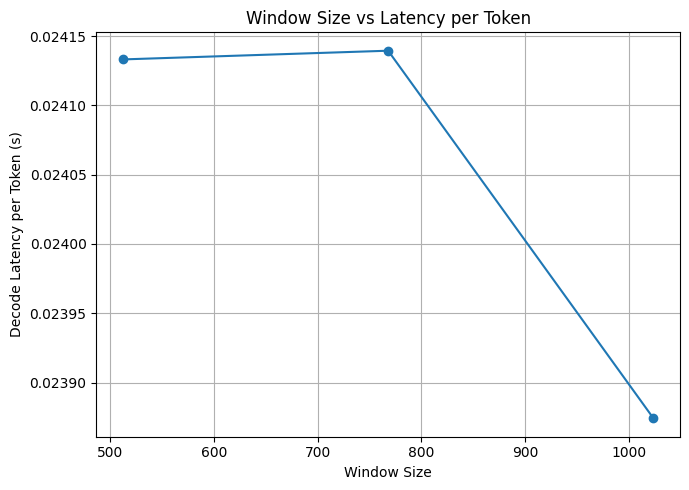

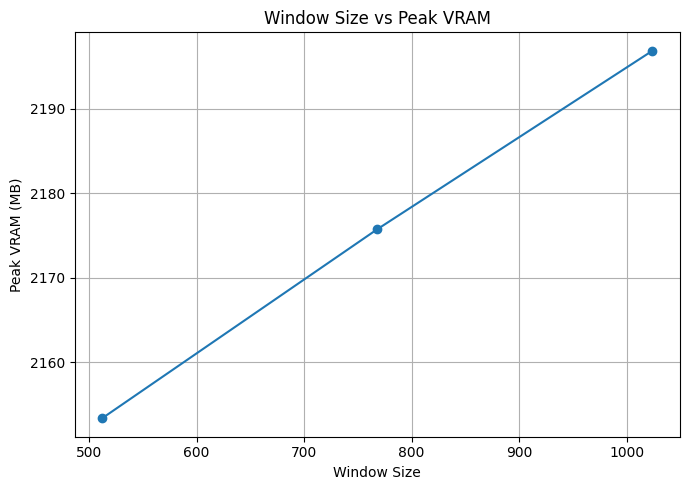

In [21]:
plt.figure(figsize=(7,5))
plt.plot(ablation_summary["window_size"], ablation_summary["decode_sec_per_token"], marker="o")
plt.xlabel("Window Size")
plt.ylabel("Decode Latency per Token (s)")
plt.title("Window Size vs Latency per Token")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/window_size_vs_latency_per_token.png")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(ablation_summary["window_size"], ablation_summary["peak_vram_mb"], marker="o")
plt.xlabel("Window Size")
plt.ylabel("Peak VRAM (MB)")
plt.title("Window Size vs Peak VRAM")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/window_size_vs_vram.png")
plt.show()

In [22]:
# Build one clean bottleneck table for presentation/report

bottleneck_rows = []

# Baseline rows
for _, row in baseline_summary.iterrows():
    bottleneck_rows.append({
        "setting": f"baseline_{int(row['prompt_tokens'])}",
        "prompt_tokens": int(row["prompt_tokens"]),
        "ttft_sec": row["ttft_sec"],
        "prefill_sec": row["prefill_sec"],
        "decode_sec": row["decode_sec"],
        "latency_per_token_sec": row["decode_sec_per_token"],
        "peak_vram_mb": row["peak_vram_mb"]
    })

# Context compare rows
for _, row in context_compare_summary.iterrows():
    bottleneck_rows.append({
        "setting": f"{row['mode']}_{int(row['prompt_tokens'])}",
        "prompt_tokens": int(row["prompt_tokens"]),
        "ttft_sec": row["ttft_sec"],
        "prefill_sec": row["prefill_sec"],
        "decode_sec": row["decode_sec"],
        "latency_per_token_sec": row["decode_sec_per_token"],
        "peak_vram_mb": row["peak_vram_mb"]
    })

# Ablation rows
for _, row in ablation_summary.iterrows():
    bottleneck_rows.append({
        "setting": f"window_{int(row['window_size'])}",
        "prompt_tokens": int(row["window_size"]),
        "ttft_sec": row["ttft_sec"],
        "prefill_sec": row["prefill_sec"],
        "decode_sec": row["decode_sec"],
        "latency_per_token_sec": row["decode_sec_per_token"],
        "peak_vram_mb": row["peak_vram_mb"]
    })

bottleneck_df = pd.DataFrame(bottleneck_rows)
bottleneck_df.to_csv("results/bottleneck_table.csv", index=False)

# Show rounded version nicely in notebook
display(
    bottleneck_df.round({
        "ttft_sec": 4,
        "prefill_sec": 4,
        "decode_sec": 4,
        "latency_per_token_sec": 4,
        "peak_vram_mb": 2
    })
)

,setting,prompt_tokens,ttft_sec,prefill_sec,decode_sec,latency_per_token_sec,peak_vram_mb
0,baseline_512,512,0.0291,0.0291,1.5565,0.0243,2153.31
1,baseline_1024,1024,0.0331,0.0331,1.5680,0.0245,2196.83
2,baseline_2048,2048,0.0413,0.0413,1.5588,0.0244,2293.37
3,full_context_1024,1024,0.0315,0.0315,1.5508,0.0242,2196.83
4,reduced_context_512,512,0.0292,0.0292,1.5591,0.0244,2153.31
5,window_512,512,0.0290,0.0290,1.5445,0.0241,2153.36
6,window_768,768,0.0292,0.0292,1.5449,0.0241,2175.74
7,window_1024,1024,0.0311,0.0311,1.5279,0.0239,2196.88


In [23]:
pretty_bottleneck = bottleneck_df.round({
    "ttft_sec": 4,
    "prefill_sec": 4,
    "decode_sec": 4,
    "latency_per_token_sec": 4,
    "peak_vram_mb": 2
})

pretty_bottleneck.style.set_caption("Bottleneck Table").background_gradient(cmap="Blues")

,setting,prompt_tokens,ttft_sec,prefill_sec,decode_sec,latency_per_token_sec,peak_vram_mb
0,baseline_512,512,0.029100,0.029100,1.556500,0.024300,2153.310000
1,baseline_1024,1024,0.033100,0.033100,1.568000,0.024500,2196.830000
2,baseline_2048,2048,0.041300,0.041300,1.558800,0.024400,2293.370000
3,full_context_1024,1024,0.031500,0.031500,1.550800,0.024200,2196.830000
4,reduced_context_512,512,0.029200,0.029200,1.559100,0.024400,2153.310000
5,window_512,512,0.029000,0.029000,1.544500,0.024100,2153.360000
6,window_768,768,0.029200,0.029200,1.544900,0.024100,2175.740000
7,window_1024,1024,0.031100,0.031100,1.527900,0.023900,2196.880000


In [24]:
# Realistic benchmark prompt set
REALISTIC_PROMPTS = {
    "factual_qa": {
        "task_prompt": (
            "Question: What are the main causes of climate change? "
            "Give a short but clear answer with two real-world examples."
        ),
        "base_context": (
            "Climate change refers to long-term changes in temperatures and weather patterns. "
            "Human activities such as burning fossil fuels, deforestation, and industrial production "
            "increase greenhouse gas concentrations and trap heat in the atmosphere."
        )
    },
    "summarization": {
        "task_prompt": (
            "Summarize the following discussion in 4 bullet points."
        ),
        "base_context": (
            "Large language model serving becomes slower as context length increases. "
            "This happens because more key-value states must be stored and accessed during decoding. "
            "As the prompt grows, memory usage rises and inference may become increasingly memory-bound."
        )
    },
    "reasoning": {
        "task_prompt": (
            "Explain step by step why increasing context length in an autoregressive language model "
            "can increase both latency and memory usage."
        ),
        "base_context": (
            "Autoregressive decoding generates one token at a time. "
            "To avoid recomputing attention for all previous tokens, the model caches key and value states. "
            "As more tokens are added, the cache grows and more memory must be accessed during decoding."
        )
    },
    "retrieval_style": {
        "task_prompt": (
            "Based on the context, answer this question: "
            "Why can retrieval-augmented generation become slower with large amounts of retrieved text?"
        ),
        "base_context": (
            "In retrieval-augmented generation, relevant chunks of text are appended to the prompt "
            "before the language model generates an answer. While this can improve factual accuracy, "
            "it also increases prompt length and therefore increases the number of cached states used during decoding."
        )
    },
    "long_context_explanation": {
        "task_prompt": (
            "Using the context, explain how prompt length, KV cache growth, and decode-time cost are related."
        ),
        "base_context": (
            "Large language models process the prompt first in a prefill stage and then generate tokens in a decode stage. "
            "The decode stage reuses cached key-value states from previous tokens. "
            "As prompts become longer, both the cache size and the amount of memory traffic can increase."
        )
    }
}

In [25]:
def make_realistic_benchmark_prompt(tokenizer, target_tokens: int, base_context: str, task_prompt: str) -> str:
    """
    Build a more realistic long prompt by repeating relevant context until target length,
    then append a task instruction at the end.
    """
    text = base_context + " "
    while True:
        ids = tokenizer(text + task_prompt, return_tensors="pt")["input_ids"][0]
        if len(ids) >= target_tokens:
            break
        text += base_context + " "

    final_ids = tokenizer(text + task_prompt, return_tensors="pt")["input_ids"][0][:target_tokens]
    return tokenizer.decode(final_ids, skip_special_tokens=True)

In [26]:
realistic_results = []

REALISTIC_CONTEXT_SETTINGS = [
    ("reduced_context", 512),
    ("full_context", 1024),
]

REALISTIC_RUNS = 2  # change to 2 if you have enough time

for prompt_name, prompt_info in REALISTIC_PROMPTS.items():
    for mode, target_len in REALISTIC_CONTEXT_SETTINGS:
        benchmark_prompt = make_realistic_benchmark_prompt(
            tokenizer=tokenizer,
            target_tokens=target_len,
            base_context=prompt_info["base_context"],
            task_prompt=prompt_info["task_prompt"]
        )

        for run_idx in range(REALISTIC_RUNS):
            result = timed_greedy_generate(
                model=model,
                tokenizer=tokenizer,
                prompt=benchmark_prompt,
                max_new_tokens=64
            )

            realistic_results.append({
                "prompt_name": prompt_name,
                "mode": mode,
                "prompt_tokens": result["prompt_tokens"],
                "generated_tokens": result["generated_tokens"],
                "ttft_sec": result["ttft_sec"],
                "prefill_sec": result["prefill_sec"],
                "decode_sec": result["decode_sec"],
                "decode_sec_per_token": result["decode_sec_per_token"],
                "total_latency_sec": result["total_latency_sec"],
                "peak_vram_mb": result["peak_vram_mb"],
                "generated_text": result["generated_text"],
                "run": run_idx + 1
            })

            print(
                f"[Realistic] Prompt={prompt_name}, Mode={mode}, Run={run_idx+1}, "
                f"TTFT={result['ttft_sec']:.4f}s, "
                f"Decode/token={result['decode_sec_per_token']:.4f}s, "
                f"Total={result['total_latency_sec']:.4f}s, "
                f"VRAM={result['peak_vram_mb']:.2f} MB"
            )

realistic_df = pd.DataFrame(realistic_results)
realistic_df.to_csv("results/realistic_benchmark_results.csv", index=False)

realistic_summary = realistic_df.groupby(["prompt_name", "mode"], as_index=False).agg({
    "generated_tokens": "mean",
    "ttft_sec": "mean",
    "prefill_sec": "mean",
    "decode_sec": "mean",
    "decode_sec_per_token": "mean",
    "total_latency_sec": "mean",
    "peak_vram_mb": "mean"
})

realistic_summary.to_csv("results/realistic_benchmark_summary.csv", index=False)
realistic_summary

[Realistic] Prompt=factual_qa, Mode=reduced_context, Run=1, TTFT=0.0303s, Decode/token=0.0238s, Total=1.5567s, VRAM=2153.36 MB
[Realistic] Prompt=factual_qa, Mode=reduced_context, Run=2, TTFT=0.0283s, Decode/token=0.0239s, Total=1.5582s, VRAM=2153.36 MB
[Realistic] Prompt=factual_qa, Mode=full_context, Run=1, TTFT=0.0309s, Decode/token=0.0240s, Total=1.5641s, VRAM=2196.88 MB
[Realistic] Prompt=factual_qa, Mode=full_context, Run=2, TTFT=0.0309s, Decode/token=0.0240s, Total=1.5670s, VRAM=2196.88 MB
[Realistic] Prompt=summarization, Mode=reduced_context, Run=1, TTFT=0.0281s, Decode/token=0.0239s, Total=1.5568s, VRAM=2153.36 MB
[Realistic] Prompt=summarization, Mode=reduced_context, Run=2, TTFT=0.0282s, Decode/token=0.0240s, Total=1.5638s, VRAM=2153.36 MB
[Realistic] Prompt=summarization, Mode=full_context, Run=1, TTFT=0.0317s, Decode/token=0.0242s, Total=1.5831s, VRAM=2196.88 MB
[Realistic] Prompt=summarization, Mode=full_context, Run=2, TTFT=0.0309s, Decode/token=0.0240s, Total=1.5693s, 

,prompt_name,mode,generated_tokens,ttft_sec,prefill_sec,decode_sec,decode_sec_per_token,total_latency_sec,peak_vram_mb
0,factual_qa,full_context,64.0,0.030930,0.030930,1.534528,0.023977,1.565535,2196.875000
1,factual_qa,reduced_context,64.0,0.029276,0.029276,1.528054,0.023876,1.557411,2153.363281
2,long_context_explanation,full_context,64.0,0.030917,0.030917,1.540686,0.024073,1.571684,2196.875000
3,long_context_explanation,reduced_context,64.0,0.029114,0.029114,1.552376,0.024256,1.581569,2153.363281
4,reasoning,full_context,64.0,0.030971,0.030971,1.532141,0.023940,1.563191,2196.875000
5,reasoning,reduced_context,64.0,0.028607,0.028607,1.546277,0.024161,1.574961,2153.363281
6,retrieval_style,full_context,64.0,0.031250,0.031250,1.546342,0.024162,1.577674,2196.875000
7,retrieval_style,reduced_context,64.0,0.028172,0.028172,1.533395,0.023959,1.561642,2153.363281
8,summarization,full_context,64.0,0.031318,0.031318,1.544792,0.024137,1.576204,2196.875000
9,summarization,reduced_context,64.0,0.028160,0.028160,1.532055,0.023938,1.560291,2153.363281


In [ ]:
# Pivot table 
realistic_pivot = realistic_summary.pivot(index="prompt_name", columns="mode", values=[
    "total_latency_sec",
    "decode_sec_per_token",
    "peak_vram_mb"
])

realistic_pivot = realistic_pivot.round(4)
realistic_pivot.to_csv("results/realistic_benchmark_pivot.csv")

display(realistic_pivot)

total_latency_sec                  \
mode                          full_context reduced_context   
prompt_name                                                  
factual_qa                          1.5655          1.5574   
long_context_explanation            1.5717          1.5816   
reasoning                           1.5632          1.5750   
retrieval_style                     1.5777          1.5616   
summarization                       1.5762          1.5603   

                         decode_sec_per_token                 peak_vram_mb  \
mode                             full_context reduced_context full_context   
prompt_name                                                                  
factual_qa                             0.0240          0.0239     2196.875   
long_context_explanation               0.0241          0.0243     2196.875   
reasoning                              0.0239          0.0242     2196.875   
retrieval_style                        0.0242          0.0240     2196.875   
summarization                          0.0241          0.0239     2196.875   

                                          
mode                     reduced_context  
prompt_name                               
factual_qa                     2153.3633  
long_context_explanation       2153.3633  
reasoning                      2153.3633  
retrieval_style                2153.3633  
summarization                  2153.3633

In [28]:
# Average across prompt types
realistic_avg = realistic_summary.groupby("mode", as_index=False).agg({
    "ttft_sec": "mean",
    "decode_sec_per_token": "mean",
    "total_latency_sec": "mean",
    "peak_vram_mb": "mean"
})

realistic_avg

,mode,ttft_sec,decode_sec_per_token,total_latency_sec,peak_vram_mb
0,full_context,0.031077,0.024058,1.570858,2196.875000
1,reduced_context,0.028666,0.024038,1.567175,2153.363281


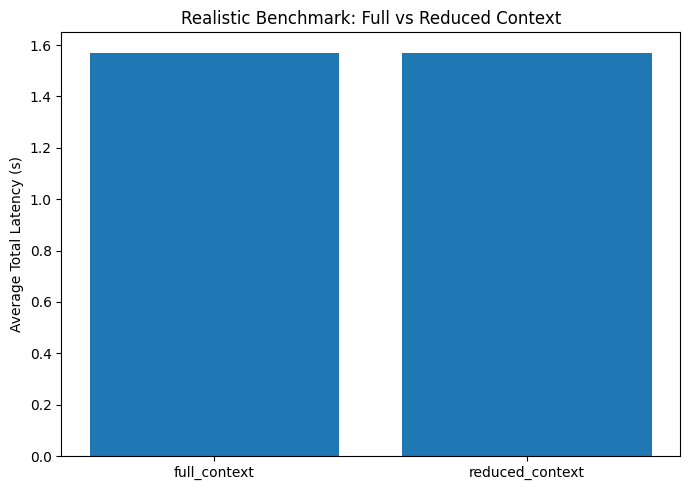

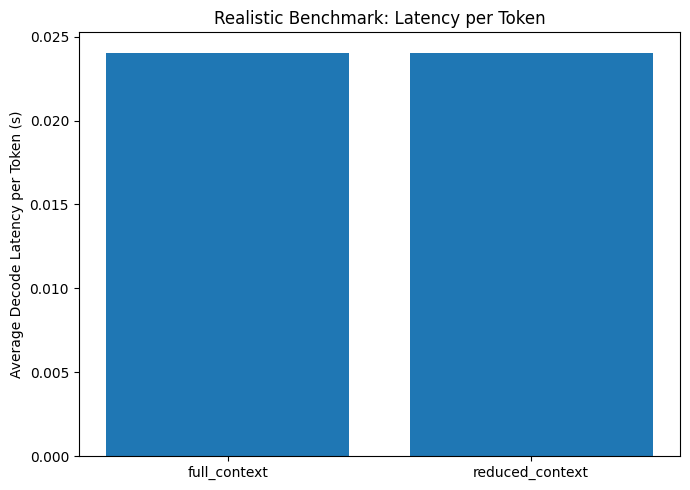

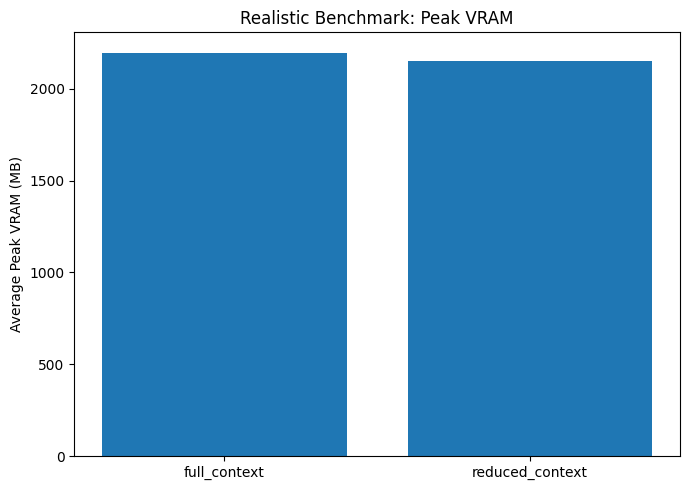

In [29]:
plt.figure(figsize=(7,5))
plt.bar(realistic_avg["mode"], realistic_avg["total_latency_sec"])
plt.ylabel("Average Total Latency (s)")
plt.title("Realistic Benchmark: Full vs Reduced Context")
plt.tight_layout()
plt.savefig("plots/realistic_benchmark_total_latency.png")
plt.show()

plt.figure(figsize=(7,5))
plt.bar(realistic_avg["mode"], realistic_avg["decode_sec_per_token"])
plt.ylabel("Average Decode Latency per Token (s)")
plt.title("Realistic Benchmark: Latency per Token")
plt.tight_layout()
plt.savefig("plots/realistic_benchmark_latency_per_token.png")
plt.show()

plt.figure(figsize=(7,5))
plt.bar(realistic_avg["mode"], realistic_avg["peak_vram_mb"])
plt.ylabel("Average Peak VRAM (MB)")
plt.title("Realistic Benchmark: Peak VRAM")
plt.tight_layout()
plt.savefig("plots/realistic_benchmark_vram.png")
plt.show()

In [30]:
realistic_final_table = realistic_summary[[
    "prompt_name",
    "mode",
    "ttft_sec",
    "decode_sec_per_token",
    "total_latency_sec",
    "peak_vram_mb"
]].round(4)

realistic_final_table.to_csv("results/realistic_final_table.csv", index=False)
display(realistic_final_table)

,prompt_name,mode,ttft_sec,decode_sec_per_token,total_latency_sec,peak_vram_mb
0,factual_qa,full_context,0.0309,0.0240,1.5655,2196.8750
1,factual_qa,reduced_context,0.0293,0.0239,1.5574,2153.3633
2,long_context_explanation,full_context,0.0309,0.0241,1.5717,2196.8750
3,long_context_explanation,reduced_context,0.0291,0.0243,1.5816,2153.3633
4,reasoning,full_context,0.0310,0.0239,1.5632,2196.8750
5,reasoning,reduced_context,0.0286,0.0242,1.5750,2153.3633
6,retrieval_style,full_context,0.0313,0.0242,1.5777,2196.8750
7,retrieval_style,reduced_context,0.0282,0.0240,1.5616,2153.3633
8,summarization,full_context,0.0313,0.0241,1.5762,2196.8750
9,summarization,reduced_context,0.0282,0.0239,1.5603,2153.3633


In [31]:
# Save outputs for manual comparison
quality_compare = realistic_df[[
    "prompt_name",
    "mode",
    "prompt_tokens",
    "ttft_sec",
    "decode_sec_per_token",
    "total_latency_sec",
    "peak_vram_mb",
    "generated_text"
]].copy()

quality_compare.to_csv("results/realistic_quality_outputs.csv", index=False)
quality_compare

,prompt_name,mode,prompt_tokens,ttft_sec,decode_sec_per_token,total_latency_sec,peak_vram_mb,generated_text
0,factual_qa,reduced_context,512,0.030298,0.023848,1.556665,2153.363281,trap heat in the atmosphere. Climate change re...
1,factual_qa,reduced_context,512,0.028255,0.023904,1.558157,2153.363281,trap heat in the atmosphere. Climate change re...
2,factual_qa,full_context,1024,0.030935,0.023954,1.564060,2196.875000,house gas concentrations and trap heat in the ...
3,factual_qa,full_context,1024,0.030926,0.024000,1.567009,2196.875000,house gas concentrations and trap heat in the ...
4,summarization,reduced_context,512,0.028146,0.023884,1.556810,2153.363281,"prompt grows, memory usage rises and inference..."
5,summarization,reduced_context,512,0.028175,0.023993,1.563772,2153.363281,"prompt grows, memory usage rises and inference..."
6,summarization,full_context,1024,0.031749,0.024239,1.583134,2196.875000,more key-value states must be stored and acces...
7,summarization,full_context,1024,0.030886,0.024036,1.569273,2196.875000,more key-value states must be stored and acces...
8,reasoning,reduced_context,512,0.028676,0.024192,1.577061,2153.363281,more memory must be accessed during decoding. ...
9,reasoning,reduced_context,512,0.028537,0.024129,1.572861,2153.363281,more memory must be accessed during decoding. ...


In [32]:
!zip -r kv_project_outputs.zip results plots

  adding: results/ (stored 0%)
  adding: results/realistic_quality_outputs.csv (deflated 79%)
  adding: results/window_ablation_summary.csv (deflated 46%)
  adding: results/realistic_benchmark_results.csv (deflated 78%)
  adding: results/perplexity_results.csv (deflated 77%)
  adding: results/window_ablation_results.csv (deflated 82%)
  adding: results/context_compare_results.csv (deflated 79%)
  adding: results/realistic_final_table.csv (deflated 63%)
  adding: results/realistic_benchmark_pivot.csv (deflated 58%)
  adding: results/realistic_benchmark_summary.csv (deflated 60%)
  adding: results/context_compare_summary.csv (deflated 43%)
  adding: results/baseline_summary.csv (deflated 47%)
  adding: results/actual_kv_optimization_summary.csv (deflated 55%)
  adding: results/baseline_results.csv (deflated 82%)
  adding: results/bottleneck_table.csv (deflated 56%)
  adding: results/tradeoff_table.csv (deflated 40%)
  adding: results/actual_kv_optimization_results.csv (deflated 87%)
  ad

In [33]:
from google.colab import files
files.download("kv_project_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>